# Clustering jerárquico aglomerativo con scikit-learn

En este notebook aplicamos el **clustering jerárquico aglomerativo** a un conjunto de datos sencillo, paso a paso.

**Qué vamos a hacer:**

1. Preparar las librerías y un estilo visual común para todas las gráficas.
2. Generar y explorar los datos.
3. Escalar las variables.
4. Construir la jerarquía completa y leer el **dendrograma**.
5. Decidir cuántos clusters usar.
6. Entrenar el modelo con `AgglomerativeClustering`.
7. Evaluar el resultado.
8. Comparar los criterios de enlace (*single*, *complete*, *average* y *Ward*).

> **Idea clave:** el algoritmo empieza con cada punto como su propio cluster y, en cada paso, fusiona los dos clusters más cercanos. Repite hasta que solo queda uno. El resultado es un árbol (dendrograma) que podemos "cortar" a la altura que queramos.

## 1. Librerías y estilo de las gráficas

| Librería | Para qué la usamos |
|---|---|
| `numpy` | Operaciones con arreglos numéricos |
| `pandas` | Mostrar resultados en tablas |
| `matplotlib` | Todas las gráficas |
| `scikit-learn` | Datos de ejemplo, escalado, modelo y métricas |
| `scipy` | Matriz de enlace y dendrograma |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

from scipy.cluster.hierarchy import linkage, dendrogram, cophenet, set_link_color_palette
from scipy.spatial.distance import pdist

Definimos **una sola vez** los colores y el estilo. Así todas las gráficas se ven consistentes y el resto del código queda limpio.

- `COLORES`: un color por cluster. Es una paleta pensada para que se distinga también con daltonismo.
- `COLOR_GRIS`: para los elementos que no son protagonistas (datos sin etiquetar, ramas por encima del corte).

In [2]:
# Paleta de colores
COLORES = ["#2a78d6", "#eb6834", "#1baf7a"]   # azul, naranja, verde-agua
COLOR_GRIS = "#b4b2a9"
COLOR_TEXTO = "#0b0b0b"
COLOR_TEXTO_SECUNDARIO = "#52514e"
COLOR_FONDO = "#fcfcfb"

# Estilo general de matplotlib
plt.rcParams.update({
    "figure.figsize": (7, 5),
    "figure.dpi": 110,
    "figure.facecolor": COLOR_FONDO,
    "axes.facecolor": COLOR_FONDO,
    "axes.edgecolor": "#d9d7d0",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,        # la cuadrícula queda detrás de los datos
    "grid.color": "#ecebe6",
    "grid.linewidth": 0.8,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlelocation": "left",
    "axes.titlepad": 12,
    "axes.labelcolor": COLOR_TEXTO_SECUNDARIO,
    "text.color": COLOR_TEXTO,
    "xtick.color": COLOR_TEXTO_SECUNDARIO,
    "ytick.color": COLOR_TEXTO_SECUNDARIO,
    "font.size": 10.5,
    "legend.frameon": False,
})

Como vamos a dibujar puntos coloreados por cluster varias veces, escribimos una pequeña función que lo haga.

Recibe los datos `X`, las etiquetas de cada punto y un título. Dibuja cada cluster con su color y agrega una leyenda.

In [3]:
def dibujar_clusters(ax, X, etiquetas, titulo):
    # Recorremos cada cluster y lo pintamos con su color
    for numero in np.unique(etiquetas):
        puntos = X[etiquetas == numero]
        ax.scatter(
            puntos[:, 0], puntos[:, 1],
            s=40,
            color=COLORES[numero % len(COLORES)],
            edgecolor=COLOR_FONDO,   # un borde del color del fondo separa los puntos que se solapan
            linewidth=0.8,
            label=f"Cluster {numero + 1}",
        )
    ax.set_title(titulo)
    ax.set_xlabel("Variable 1 (escalada)")
    ax.set_ylabel("Variable 2 (escalada)")
    ax.legend(loc="best")

## 2. Los datos

Usamos `make_blobs`, que genera nubes de puntos alrededor de unos centros:

- `n_samples=150`: 150 puntos.
- `centers=3`: 3 grupos.
- `random_state=42`: fija la semilla para que el resultado sea siempre el mismo.

La función también devuelve `y_real`, el grupo verdadero de cada punto. **En un problema real no tendríamos esta información** (por eso el aprendizaje es *no supervisado*). Aquí la guardamos solo para evaluar el resultado al final. El modelo nunca la ve.

In [4]:
X, y_real = make_blobs(n_samples=150, centers=3, random_state=42)

print("Forma de X:", X.shape)   # (filas = puntos, columnas = variables)
print("Primeras 5 filas:")
print(X[:5].round(2))

Forma de X: (150, 2)
Primeras 5 filas:
[[-2.55 10.58]
 [-3.35  8.71]
 [-6.6  -7.5 ]
 [ 6.53  2.15]
 [-6.36 -6.37]]


### Primera mirada a los datos

Dibujamos los puntos **sin colores**, tal como los vería el algoritmo: sin saber a qué grupo pertenece cada uno.

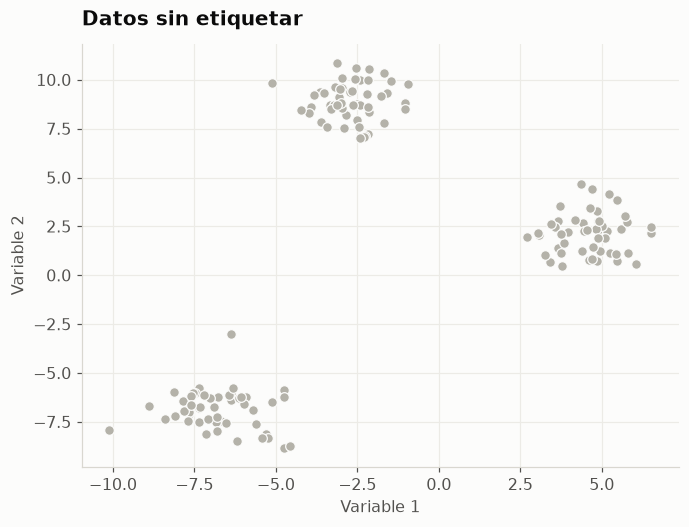

In [5]:
fig, ax = plt.subplots()
ax.scatter(X[:, 0], X[:, 1], s=40, color=COLOR_GRIS, edgecolor=COLOR_FONDO, linewidth=0.8)
ax.set_title("Datos sin etiquetar")
ax.set_xlabel("Variable 1")
ax.set_ylabel("Variable 2")
plt.show()

A simple vista se distinguen tres grupos bien separados. Es un caso fácil a propósito, para concentrarnos en entender cada paso del algoritmo.

## 3. Escalar las variables

El clustering jerárquico se basa **por completo en distancias**. Si una variable tiene valores en miles y otra en décimas, la primera domina la distancia y la segunda casi no cuenta.

`StandardScaler` transforma cada variable para que tenga **media 0 y desviación estándar 1**:

$$z = \frac{x - \text{media}}{\text{desviación estándar}}$$

Escalar antes de cualquier algoritmo basado en distancias (k-means, KNN, clustering jerárquico) es una buena práctica que recomienda Géron en *Hands-On Machine Learning*.

In [6]:
escalador = StandardScaler()
X_esc = escalador.fit_transform(X)

# sumar 0 evita que numpy muestre "-0." cuando el valor es un cero negativo muy pequeño
print("Media de cada variable:     ", X_esc.mean(axis=0).round(2) + 0)
print("Desviación de cada variable:", X_esc.std(axis=0).round(2))

Media de cada variable:      [0. 0.]
Desviación de cada variable: [1. 1.]


## 4. Construir la jerarquía con SciPy

Aunque el modelo final lo entrenaremos con scikit-learn, **SciPy** nos deja ver el árbol completo. Eso es justo lo que queremos entender.

`linkage(X, method="ward")` ejecuta el algoritmo aglomerativo y devuelve la **matriz de enlace `Z`**. Tiene una fila por cada fusión (`n − 1` filas) y 4 columnas:

| Columna | Significado |
|---|---|
| `cluster_a`, `cluster_b` | Los dos clusters que se fusionan. Del `0` al `n−1` son los puntos originales; desde `n` en adelante, los clusters creados en fusiones anteriores. |
| `altura` | La distancia de enlace a la que se fusionaron. |
| `tamaño` | Cuántos puntos tiene el nuevo cluster. |

Usamos el criterio de **Ward**, que en cada paso fusiona el par que **menos aumenta la varianza dentro de los clusters**.

In [7]:
Z = linkage(X_esc, method="ward")

print("Forma de Z:", Z.shape)   # 149 fusiones para 150 puntos

tabla_z = pd.DataFrame(Z, columns=["cluster_a", "cluster_b", "altura", "tamaño"])
tabla_z = tabla_z.astype({"cluster_a": int, "cluster_b": int, "tamaño": int})
tabla_z.round(3).tail(6)   # las últimas 6 fusiones

Forma de Z: (149, 4)


,cluster_a,cluster_b,altura,tamaño
143,277,285,1.110,20
144,290,291,1.331,50
145,284,292,1.549,50
146,289,293,1.853,50
147,294,295,13.005,100
148,296,297,20.299,150


Fíjate en la columna `altura` de las últimas filas. Las fusiones van subiendo poco a poco, hasta que las dos últimas **saltan de golpe**. Esas dos últimas fusiones unen grupos que están realmente separados. Lo veremos mejor en el dendrograma.

### 4.1 El dendrograma

Cómo leerlo:

- **Eje vertical:** la altura a la que se fusionan los grupos. Cuanto más alta la unión, más distintos eran.
- **Eje horizontal:** el orden de las hojas **no significa nada**. Dos hojas vecinas no son necesariamente parecidas; lo que importa es la altura a la que se unen.
- **Cortar el árbol:** una línea horizontal separa los datos en tantos clusters como ramas atraviesa.

Con 150 puntos el árbol completo sería ilegible, así que mostramos solo las **últimas 30 ramas** (`truncate_mode="lastp"`). Un número entre paréntesis, como `(12)`, indica que esa hoja agrupa 12 puntos. Un número sin paréntesis, como `62`, es el índice de un único punto.

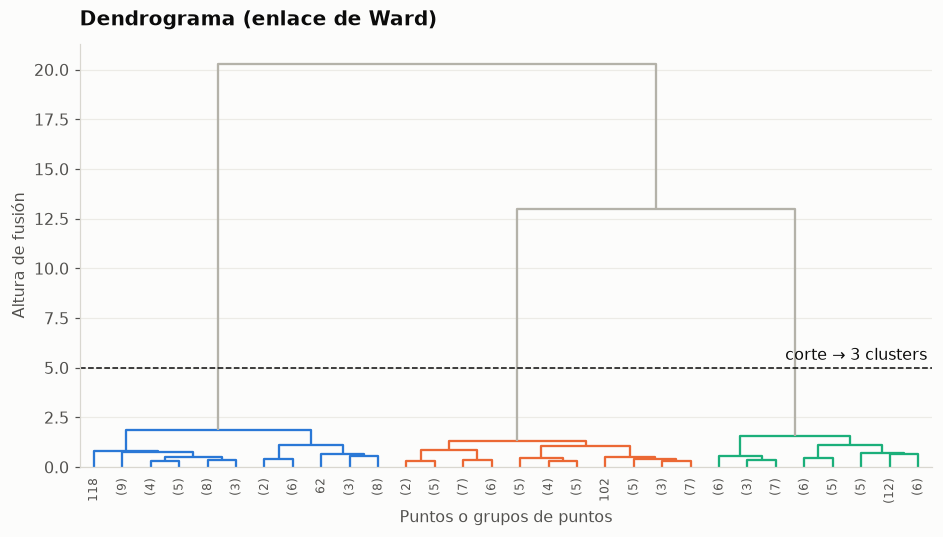

In [8]:
ALTURA_CORTE = 5   # elegida mirando el gran salto en las alturas

set_link_color_palette(COLORES)   # colores de las ramas por debajo del corte

fig, ax = plt.subplots(figsize=(10, 5))
dendrogram(
    Z,
    truncate_mode="lastp",   # mostrar solo las últimas p ramas
    p=30,
    color_threshold=ALTURA_CORTE,
    above_threshold_color=COLOR_GRIS,
    leaf_rotation=90,
    leaf_font_size=8,
    ax=ax,
)
ax.axhline(ALTURA_CORTE, color=COLOR_TEXTO, linestyle="--", linewidth=1)
ax.text(ax.get_xlim()[1], ALTURA_CORTE + 0.4, "corte → 3 clusters ", ha="right", color=COLOR_TEXTO)

ax.set_title("Dendrograma (enlace de Ward)")
ax.set_ylabel("Altura de fusión")
ax.set_xlabel("Puntos o grupos de puntos")
ax.grid(axis="x", visible=False)
plt.show()

Las tres ramas de color se forman a poca altura y se unen entre sí mucho más arriba. Esa gran distancia vertical es la señal de que hay **3 grupos naturales**.

*Nota:* SciPy asigna los colores de las ramas de izquierda a derecha, así que no tienen por qué coincidir con los colores de las gráficas de dispersión.

## 5. ¿Cuántos clusters?

El clustering jerárquico no nos obliga a fijar `k` antes de empezar, pero al final hay que elegir dónde cortar. Usamos dos criterios complementarios.

### 5.1 El salto en la altura de fusión

Para cada número de clusters `k`, miramos la altura de la fusión que **reduciría** los clusters de `k` a `k − 1`. Si esa fusión es muy costosa (una barra muy alta), significa que para bajar de `k` grupos tendríamos que juntar grupos muy distintos. Por eso conviene quedarse en `k`.

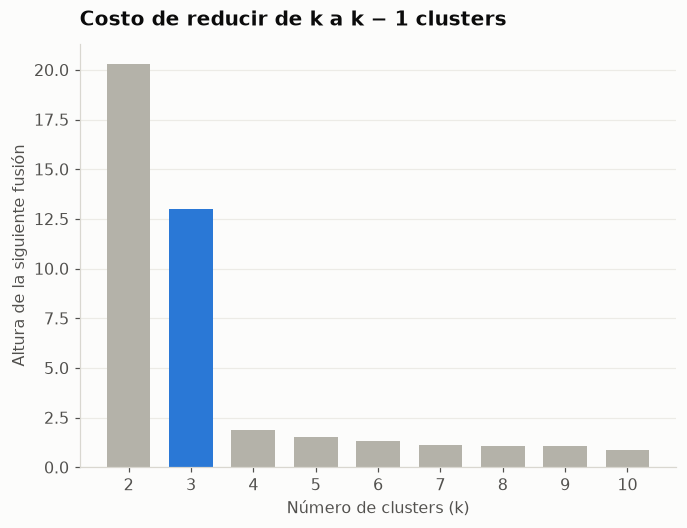

In [9]:
valores_k = np.arange(2, 11)       # k = 2, 3, ..., 10
alturas = Z[-(valores_k - 1), 2]   # altura de la fusión que pasa de k a k-1 clusters

colores_barras = []
for k in valores_k:
    if k == 3:
        colores_barras.append(COLORES[0])
    else:
        colores_barras.append(COLOR_GRIS)

fig, ax = plt.subplots()
ax.bar(valores_k, alturas, color=colores_barras, width=0.7)
ax.set_title("Costo de reducir de k a k − 1 clusters")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Altura de la siguiente fusión")
ax.set_xticks(valores_k)
ax.grid(axis="x", visible=False)
plt.show()

Léela de derecha a izquierda. Desde `k = 10` hasta `k = 4` las barras son bajas: pasar de 10 a 9 clusters, de 9 a 8… o de 4 a 3 cuesta poco, porque se unen grupos parecidos. En cambio, pasar de **3 a 2** clusters cuesta muchísimo (la barra azul). Por lo tanto, `k = 3` es el punto natural de corte.

### 5.2 El coeficiente de silueta

La **silueta** mide, para cada punto, qué tan cerca está de su propio cluster comparado con el cluster vecino más cercano:

- cerca de **1**: el punto está bien asignado;
- cerca de **0**: está en la frontera entre dos clusters;
- **negativa**: probablemente está en el cluster equivocado.

Calculamos la silueta promedio para varios valores de `k` y nos quedamos con el mayor.

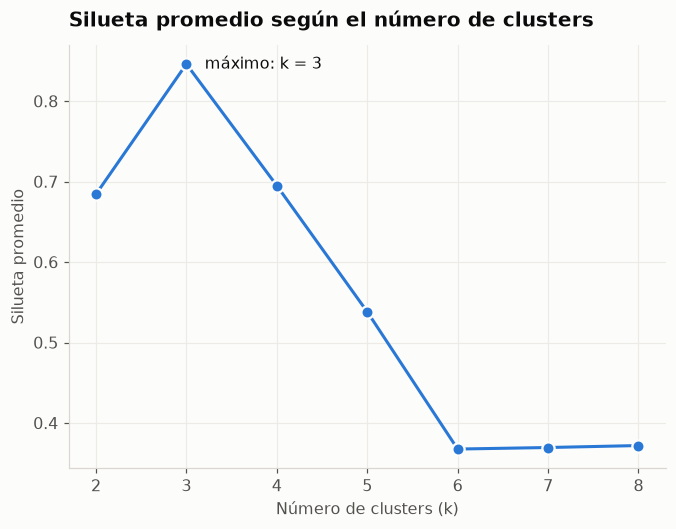

In [10]:
valores_k = range(2, 9)
siluetas = []

for k in valores_k:
    modelo_k = AgglomerativeClustering(n_clusters=k, linkage="ward")
    etiquetas_k = modelo_k.fit_predict(X_esc)
    siluetas.append(silhouette_score(X_esc, etiquetas_k))

mejor_k = list(valores_k)[np.argmax(siluetas)]

fig, ax = plt.subplots()
ax.plot(valores_k, siluetas, color=COLORES[0], linewidth=2, marker="o", markersize=8,
        markeredgecolor=COLOR_FONDO, markeredgewidth=1.5)
ax.annotate(f"máximo: k = {mejor_k}", xy=(mejor_k, max(siluetas)),
            xytext=(12, 0), textcoords="offset points", va="center")
ax.set_title("Silueta promedio según el número de clusters")
ax.set_xlabel("Número de clusters (k)")
ax.set_ylabel("Silueta promedio")
plt.show()

Los dos criterios coinciden: **k = 3**.

## 6. El modelo en scikit-learn

`AgglomerativeClustering` es el estimador de scikit-learn para este algoritmo. Sus parámetros principales son:

| Parámetro | Qué hace | Valor que usamos |
|---|---|---|
| `n_clusters` | Cuántos clusters devolver (equivale a cortar el árbol) | `3` |
| `linkage` | Criterio de enlace: `"ward"`, `"complete"`, `"average"` o `"single"` | `"ward"` |
| `metric` | Distancia entre puntos (con Ward debe ser `"euclidean"`) | por defecto |
| `distance_threshold` | Alternativa a `n_clusters`: cortar a una altura fija | no se usa |

Usamos `fit_predict` porque este modelo **no tiene `predict()`**. Asigna etiquetas solo a los datos con los que se entrena. Para clasificar puntos nuevos habría que entrenar después un clasificador, por ejemplo `KNeighborsClassifier`, con estas etiquetas.

In [11]:
modelo = AgglomerativeClustering(n_clusters=3, linkage="ward")
etiquetas = modelo.fit_predict(X_esc)

print("Etiqueta de los primeros 10 puntos:", etiquetas[:10])
print("Puntos en cada cluster:            ", np.bincount(etiquetas))

Etiqueta de los primeros 10 puntos: [2 2 0 1 0 1 2 2 0 1]
Puntos en cada cluster:             [50 50 50]


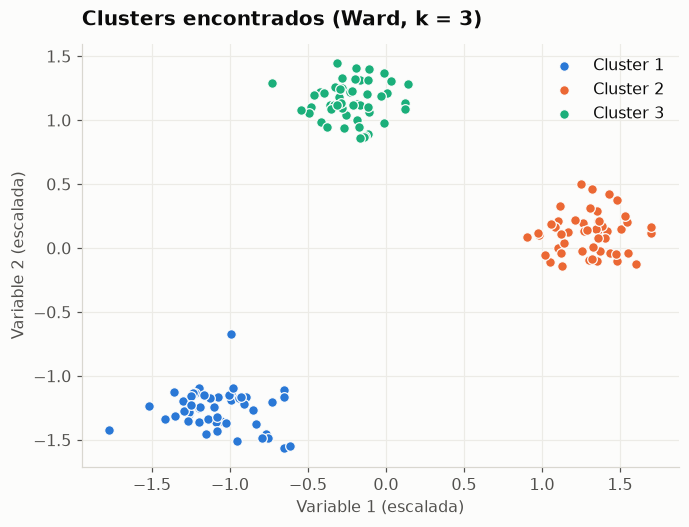

In [12]:
fig, ax = plt.subplots()
dibujar_clusters(ax, X_esc, etiquetas, "Clusters encontrados (Ward, k = 3)")
plt.show()

## 7. Evaluación

Usamos tres métricas, cada una responde una pregunta distinta:

| Métrica | Pregunta | Necesita etiquetas reales |
|---|---|---|
| **Silueta** | ¿Los clusters son compactos y están separados? | No |
| **Correlación cofenética** | ¿El dendrograma respeta las distancias originales entre puntos? | No |
| **ARI** (*Adjusted Rand Index*) | ¿Coinciden los clusters con los grupos reales? | Sí |

**¿Por qué ARI y no *accuracy*?** Los números de cluster son arbitrarios. El modelo puede llamar "cluster 0" a lo que en `y_real` es el grupo 2. ARI compara **cómo se agrupan los puntos**, no los nombres. Vale 1 si la agrupación es idéntica y alrededor de 0 si es aleatoria.

In [13]:
silueta = silhouette_score(X_esc, etiquetas)
correlacion_cofenetica, _ = cophenet(Z, pdist(X_esc))
ari = adjusted_rand_score(y_real, etiquetas)

print(f"Silueta promedio:        {silueta:.3f}")
print(f"Correlación cofenética:  {correlacion_cofenetica:.3f}")
print(f"ARI con grupos reales:   {ari:.3f}")

Silueta promedio:        0.846
Correlación cofenética:  0.976
ARI con grupos reales:   1.000


Los tres valores son altos y el ARI es 1: el modelo recuperó exactamente los grupos originales. Es lo esperable en un conjunto tan bien separado.

## 8. Comparar los criterios de enlace

El criterio de enlace define cómo se mide la distancia **entre dos clusters**:

| Enlace | Distancia entre clusters A y B | Tiende a formar |
|---|---|---|
| `single` | la del par de puntos **más cercano** | cadenas; sigue formas alargadas |
| `complete` | la del par de puntos **más lejano** | grupos compactos de tamaño parecido |
| `average` | el **promedio** de todas las parejas | un punto intermedio |
| `ward` | el **aumento de varianza** al fusionar | grupos esféricos de tamaño parecido |

Primero los comparamos con nuestros datos.

In [14]:
enlaces = ["single", "complete", "average", "ward"]
filas = []

for enlace in enlaces:
    etiquetas_e = AgglomerativeClustering(n_clusters=3, linkage=enlace).fit_predict(X_esc)
    cofenetica, _ = cophenet(linkage(X_esc, method=enlace), pdist(X_esc))
    filas.append({
        "enlace": enlace,
        "silueta": silhouette_score(X_esc, etiquetas_e),
        "cofenética": cofenetica,
        "ARI": adjusted_rand_score(y_real, etiquetas_e),
    })

pd.DataFrame(filas).set_index("enlace").round(3)

,silueta,cofenética,ARI
enlace,,,
single,0.846,0.976,1.0
complete,0.846,0.974,1.0
average,0.846,0.978,1.0
ward,0.846,0.976,1.0


**Todos dan el mismo resultado.** Cuando los grupos están tan separados, cualquier criterio los encuentra. Las diferencias aparecen cuando los datos tienen formas más difíciles.

### 8.1 Un caso más difícil: dos lunas

`make_moons` genera dos medias lunas entrelazadas. Son grupos **no convexos**: no se pueden separar con una línea recta ni se parecen a una nube redonda.

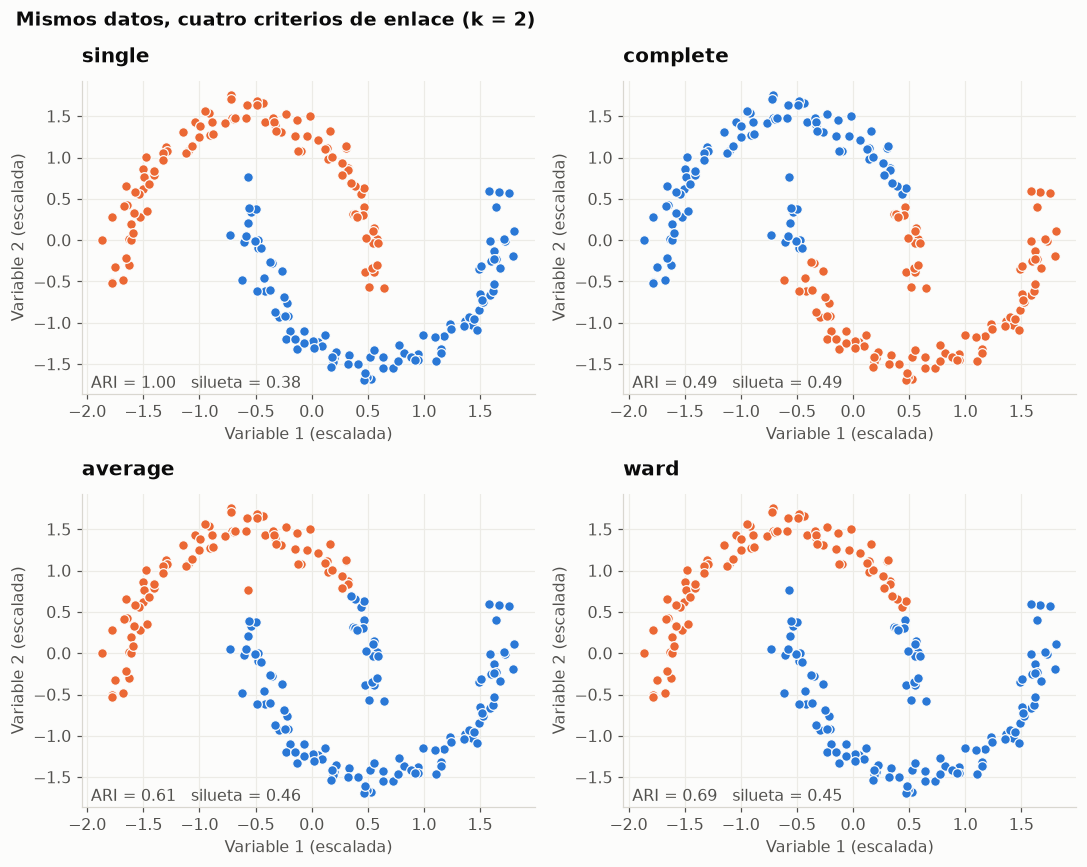

In [15]:
X_lunas, y_lunas = make_moons(n_samples=200, noise=0.06, random_state=42)
X_lunas = StandardScaler().fit_transform(X_lunas)

fig, ejes = plt.subplots(2, 2, figsize=(10, 8))
ejes = ejes.flatten()   # convertimos la cuadrícula 2x2 en una lista de 4 ejes

for i in range(len(enlaces)):
    enlace = enlaces[i]
    etiquetas_l = AgglomerativeClustering(n_clusters=2, linkage=enlace).fit_predict(X_lunas)
    ari_l = adjusted_rand_score(y_lunas, etiquetas_l)
    silueta_l = silhouette_score(X_lunas, etiquetas_l)

    dibujar_clusters(ejes[i], X_lunas, etiquetas_l, f"{enlace}")
    ejes[i].text(0.02, 0.02, f"ARI = {ari_l:.2f}   silueta = {silueta_l:.2f}",
                 transform=ejes[i].transAxes, color=COLOR_TEXTO_SECUNDARIO)
    ejes[i].legend().remove()

fig.suptitle("Mismos datos, cuatro criterios de enlace (k = 2)", fontweight="bold", x=0.02, ha="left")
fig.tight_layout()
plt.show()

**Qué observamos:**

- **`single`** separa las dos lunas perfectamente (ARI = 1). Como une por el vecino más cercano, "camina" a lo largo de cada luna.
- **`complete`**, **`average`** y **`ward`** cortan las lunas por la mitad. Buscan grupos compactos y redondeados, y esa forma no existe en estos datos.
- **La silueta engaña aquí:** `single` tiene la silueta *más baja* aunque es el único correcto. La silueta favorece los grupos redondos y compactos, así que no sirve para evaluar formas alargadas.

**Lección:** no existe un criterio de enlace universalmente mejor. Elige según la forma que esperas en tus datos, compara varios y no confíes en una sola métrica.

## 9. Conclusiones

1. El clustering jerárquico construye **toda la jerarquía** de agrupaciones. Elegir `k` es una decisión posterior: dónde cortar el dendrograma.
2. **Escalar** las variables es obligatorio, porque todo depende de distancias.
3. Para elegir `k`, combina el **salto en las alturas** del dendrograma con la **silueta**.
4. El **criterio de enlace** es la decisión más importante. Ward funciona muy bien con grupos redondos; single con formas alargadas.
5. `AgglomerativeClustering` no tiene `predict()`, y su costo en memoria crece como `n²`. Es ideal para conjuntos pequeños y medianos (hasta unas decenas de miles de puntos).

## 10. Ejercicios propuestos

1. Cambia `ALTURA_CORTE` a `15` y vuelve a dibujar el dendrograma. ¿Cuántos clusters obtienes?
2. En `make_blobs`, agrega `cluster_std=2.5` para que los grupos se solapen. ¿Siguen coincidiendo los cuatro enlaces?
3. Entrena el modelo con `distance_threshold=5` y `n_clusters=None` en lugar de `n_clusters=3`. ¿Obtienes el mismo resultado?
4. En las lunas, aumenta `noise` a `0.12`. ¿Sigue funcionando `single`? ¿Por qué el ruido le afecta tanto?

## Referencias

- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras and TensorFlow*, 3.ª ed., cap. 9.
- Ward, J. H. (1963). Hierarchical grouping to optimize an objective function. *JASA*, 58(301).
- Documentación de scikit-learn: [`AgglomerativeClustering`](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) y [Hierarchical clustering](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering).
- Documentación de SciPy: [`scipy.cluster.hierarchy`](https://docs.scipy.org/doc/scipy/reference/cluster.hierarchy.html).